# 第20课 · 🎨 把复杂变换拆成几步简单动作——LU / QR / SVD 分解的几何图谱

> 来自《The Art of Linear Algebra》。把矩阵拆成几块的乘积：

`A=LU`(消元) · `A=QR`(正交化) · `S=QΛQᵀ`(对称特征) · `A=UΣVᵀ`(SVD)。

**学习目标**
1. 用 `laviz` 的 `show_factorization` 把 LU 分解画成「下三角消元 × 上三角阶梯」的几何步骤
2. 观察 QR 分解中 Q 的正交性（`QᵀQ = I`）和 R 的上三角结构，理解 Gram-Schmidt 正交化含义
3. 对比对称矩阵谱定理 `S = QΛQᵀ` 与一般矩阵 SVD `A = UΣVᵀ` 的几何结构差异
4. 通过奇异值序列判断矩阵有效秩：保留前 k 个奇异值可重建主要信息，丢掉小奇异值即滤噪
5. 理解 Aurora mel 频谱矩阵的 SVD 低秩近似：保留大奇异值、丢掉小奇异值，就能把主结构和背景噪声分开

**为什么对 Aurora 重要**：MFCC 提取流水线里的 Mel 滤波器矩阵可做 SVD 降维，QR 分解用于数值稳定的最小二乘；理解几何含义，代码调参时才不会乱猜。

← **上一课**　[L19 · 矩阵变换图解](L19_visual_multiply.ipynb)

> 上节课学习了 **矩阵变换图解**：旋转、缩放、剪切与「列的线性组合」的视觉演示。  
> 本课将探讨 **分解图谱**。

## 本课剧情：名字 → 几何动作地图

> **本课定位**：建立 **LU / QR / SVD 的名字与几何动作** 对照，**不推完整证明**。  
> 消元细节见 L15，SVD 低秩见 L14——这里用图把三套「拆法」摆在同一张地图上。

矩阵分解 = 把复杂变换拆成几步简单动作：
- **LU**：消元的矩阵语言（下三角 × 上三角）
- **QR**：先转成正交方向，再拉伸
- **SVD**：旋转 → 轴向拉伸 → 再旋转（适用于任意形状矩阵）

看图记住「每一步在坐标系上干什么」即可；需要深算时再回对应课。

In [1]:
# Aurora matplotlib bootstrap
from pathlib import Path
import sys

_root = None
_cwd = Path.cwd().resolve()
for _candidate in (_cwd, *_cwd.parents):
    if (_candidate / '_matplotlib_bootstrap.py').exists():
        _root = _candidate
        break
if _root is None:
    _notebooks_dir = _cwd / 'notebooks'
    if _notebooks_dir.exists():
        for _found in _notebooks_dir.rglob('_matplotlib_bootstrap.py'):
            _root = _found.parent
            break
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from _matplotlib_bootstrap import apply as _aurora_mpl_apply
_aurora_mpl_apply()


In [2]:
import numpy as np
from aurora.laviz import style, show_factorization, heatmap
style(); print('就绪')

就绪


## 符号入口：先看形状，再看运算

分解式中每个因子都是矩阵，理解分解就是依次理解各因子的几何效果。LU 中 L 做行剪切、U 做上三角缩放；QR 中 Q 是旋转、R 是上三角拉伸；SVD 中 U 和 V 是旋转、Σ 是轴向拉伸。

## 动手观察：线代对象先看形状，再看意义

运行下面的代码，注意各因子的 shape：L 和 U 为何都是方阵，Q 的列为何两两正交，SVD 中 U、Σ、Vᵀ 的维度如何与原矩阵 A 的行列数对应。

In [3]:
import numpy as np

# QR 分解：A = Q R（Q 正交，R 上三角）
A = np.array([[1.,2.],[3.,4.],[5.,6.]])
Q, R = np.linalg.qr(A)
print('Q（正交列）=\n', np.round(Q, 4))
print('R（上三角）=\n', np.round(R, 4))
print('Q^T @ Q =\n', np.round(Q.T @ Q, 10))  # 应为 I
print('重建误差 =', np.max(np.abs(A - Q @ R)))


Q（正交列）=
 [[-0.169   0.8971]
 [-0.5071  0.276 ]
 [-0.8452 -0.345 ]]
R（上三角）=
 [[-5.9161 -7.4374]
 [ 0.      0.8281]]
Q^T @ Q =
 [[ 1. -0.]
 [-0.  1.]]
重建误差 = 8.881784197001252e-16


### 停一下：「正交」到底在说什么？为什么 QᵀQ = I 就叫正交？

高中里学过的"垂直"，说的是两条直线的夹角是90°，判断方法是点乘：两个向量 $a, b$ 垂直 $\iff a\cdot b = 0$。上面的 Q 是一个矩阵，但它的"正交"其实就是这个高中知识的直接推广——只不过我们一次性检查很多对向量。

把 Q 看成是"并排放着的几根柱子"：Q 的每一**列**都是一个向量。"Q 的列两两正交"这句话，拆开来其实是两件事：

1. 任取 Q 的两根不同的柱子 $q_i, q_j$（$i\neq j$），它们必须垂直：$q_i \cdot q_j = 0$。
2. 每根柱子自己的长度都恰好是1（"单位向量"）：$q_i \cdot q_i = 1$。

现在看 $Q^\top Q$ 这个矩阵乘法在算什么。$Q^\top$ 的第 $i$ 行，就是 $Q$ 的第 $i$ 列（转置只是把列摆成了行）。矩阵乘法的第 $(i,j)$ 个位置，是"$Q^\top$ 的第 $i$ 行"点乘"$Q$ 的第 $j$ 列"——也就是 $q_i \cdot q_j$。换句话说：

$$Q^\top Q \text{ 这一整个表格，就是把"任意两根柱子的点积"一次性摆出来了。}$$

如果所有柱子两两垂直（非对角位置全是0）、每根柱子长度都是1（对角线全是1），这张表恰好就是单位矩阵 $I$。反过来，如果算出来 $Q^\top Q = I$，也能倒推出"列两两垂直、长度为1"——这就是数学上把"正交矩阵"定义为 $Q^\top Q = I$ 的原因：这条公式，只是"两两垂直 + 单位长度"这句话的矩阵写法。

下面用两个手算的向量验证一下这个对应关系，顺便说清楚这里 Q 为什么是 3×2（不是方阵）——这跟 numpy 默认用的 **reduced QR**（精简 QR）有关。

In [4]:
import numpy as np

# 1) "正交"到底在说什么？先用两个具体向量手算点积
q1 = np.array([0.6, 0.8])
q2 = np.array([-0.8, 0.6])
print('q1·q1 =', q1 @ q1, ' (长度的平方，=1 说明 q1 是单位向量)')
print('q2·q2 =', q2 @ q2, ' (同理，q2 也是单位向量)')
print('q1·q2 =', q1 @ q2, ' (=0 说明两个向量垂直)')

Qtoy = np.column_stack([q1, q2])
print('\n把 q1, q2 拼成 Qtoy 的两列，QtoyᵀQtoy =\n', np.round(Qtoy.T @ Qtoy, 10))
print('→ 对角线 = 各列自己的点积(长度平方=1)，非对角线 = 不同列的点积(垂直=0)，正好是单位矩阵')

# 2) reduced QR vs full QR：形状对不上时到底发生了什么
A32 = np.array([[1., 2.], [3., 4.], [5., 6.]])
Q_reduced, R_reduced = np.linalg.qr(A32, mode='reduced')
Q_full, R_full = np.linalg.qr(A32, mode='complete')
print('\nreduced QR:  Q shape =', Q_reduced.shape, ' R shape =', R_reduced.shape)
print('complete QR: Q shape =', Q_full.shape, ' R shape =', R_full.shape)
print('两种模式都满足 Q@R = A：',
      np.allclose(Q_reduced @ R_reduced, A32), np.allclose(Q_full @ R_full, A32))
print('→ reduced 只保留 A 的两列真正用到的方向；complete 把 Q 补成 3×3 的完整旋转，')
print('  多出来的第3列跟 A 的列空间无关，只是为了让 Q 变成"标准意义"里的方阵。')


q1·q1 = 1.0  (长度的平方，=1 说明 q1 是单位向量)
q2·q2 = 1.0  (同理，q2 也是单位向量)
q1·q2 = 0.0  (=0 说明两个向量垂直)

把 q1, q2 拼成 Qtoy 的两列，QtoyᵀQtoy =
 [[1. 0.]
 [0. 1.]]
→ 对角线 = 各列自己的点积(长度平方=1)，非对角线 = 不同列的点积(垂直=0)，正好是单位矩阵

reduced QR:  Q shape = (3, 2)  R shape = (2, 2)
complete QR: Q shape = (3, 3)  R shape = (3, 2)
两种模式都满足 Q@R = A： True True
→ reduced 只保留 A 的两列真正用到的方向；complete 把 Q 补成 3×3 的完整旋转，
  多出来的第3列跟 A 的列空间无关，只是为了让 Q 变成"标准意义"里的方阵。


## 代码实验：遍历几个向量（vector），观察矩阵如何改变它们

对同一个矩阵 A 输入几组测试向量，观察 A 把它们分别旋转和拉伸了多少——SVD 中 Σ 的对角值决定了每个方向上的拉伸幅度。

In [5]:
import numpy as np

# 同一矩阵三种分解的比较
A = np.array([[2.,1.,1.],[4.,3.,3.],[8.,7.,9.]])
# LU
# LU 分解（Doolittle，无主元选取，纯 numpy）
def _lu(A):
    n = len(A)
    L, U = np.eye(n), A.copy().astype(float)
    for j in range(n):
        for i in range(j+1, n):
            L[i,j] = U[i,j] / U[j,j]
            U[i] -= L[i,j] * U[j]
    return L, U
L, U = _lu(A)
print(f'LU: L对角线={np.round(np.diag(L),4)}, U对角线={np.round(np.diag(U),4)}')
# QR
Q, R = np.linalg.qr(A)
print(f'QR: R对角线={np.round(np.diag(R),4)}')
# SVD
s = np.linalg.svd(A, compute_uv=False)
print(f'SVD: 奇异值={np.round(s,4)}')
print(f'rank={np.linalg.matrix_rank(A)}')


LU: L对角线=[1. 1. 1.], U对角线=[2. 1. 2.]
QR: R对角线=[-9.1652  0.8165 -0.5345]
SVD: 奇异值=[15.2486  1.1963  0.2193]
rank=3


## 1. A = LU（高斯消元（Gaussian elimination）的矩阵形式）

下三角 L × 上三角 U。对应你在 `L15` 学的消元。

**为什么这样设计**：这节用 laviz 图，不用纯公式，因为每个因子都有对应的几何动作，图比符号更直接。以 SVD 为例：A=UΣVᵀ 读成三步——Vᵀ 把输入旋转到矩阵的主方向，Σ 沿这些方向按奇异值（singular value）大小拉伸，U 再旋转到输出空间；laviz 把三步叠加显示，分解的结构立刻可读。LU 同理：L 的次对角元素是消元乘数（行剪切），U 是阶梯形上三角——两步合起来完整记录了高斯消元的每一行操作。

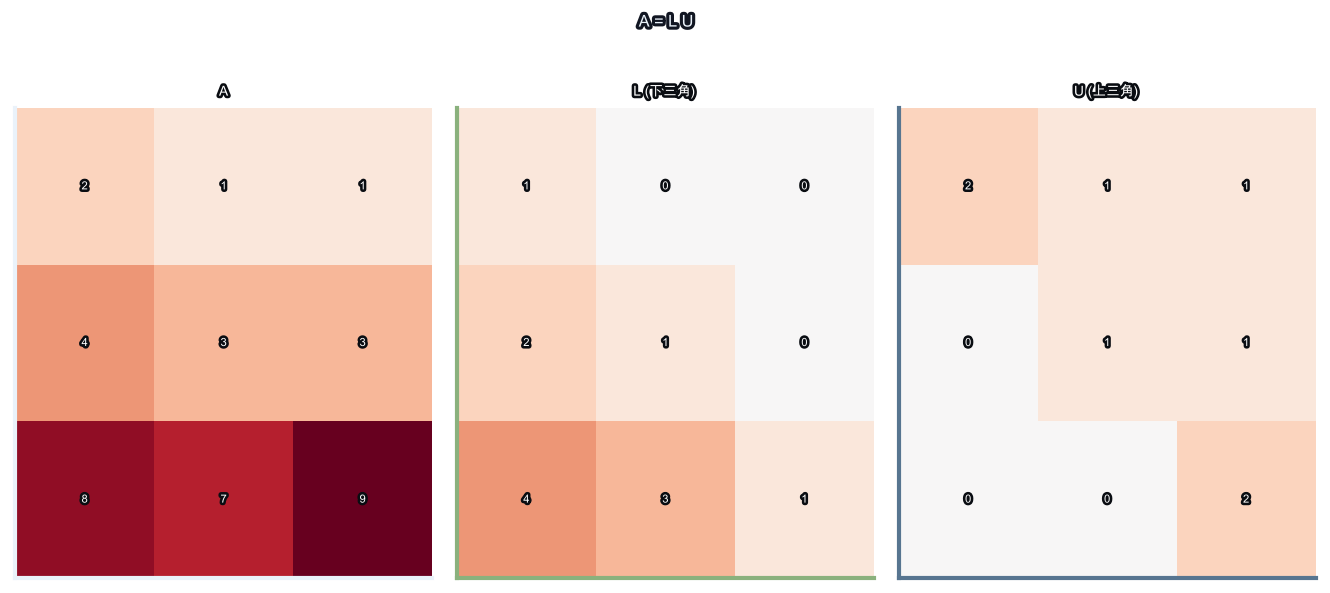

In [6]:
A = np.array([[2.,1,1],[4,3,3],[8,7,9]])
# 用 _lu(A) 算法计算 L, U（与 L15 的行变换同源）
L, U = _lu(A)
assert np.allclose(L @ U, A)
show_factorization(A, [L, U], ['L (下三角)', 'U (上三角)'],
                   modes=['#8AB17D', '#577590'], title='A = L U');

### 停一下：为什么 L 的对角线永远是 1？

回忆一下高斯消元在做什么：为了把第 2 行开头的数字消成 0，你会做"第2行 ← 第2行 − 倍数 × 第1行"；为了消第3行，再做"第3行 ← 第3行 − 倍数 × 第1行 − 倍数 × 第2行"……每一次操作用到的那个"倍数"，就记在 L 的对应位置里（比如 `L[2,1]` 记的是"第2行减去了多少倍的第1行"）。

那 L 的对角线，比如 `L[1,1]`、`L[2,2]`，记的是什么？按同样的逻辑，它应该记录"第 i 行减去了多少倍的第 i 行"——但这件事从来不会发生：高斯消元只会用**前面**已经处理好的行去消**当前**行开头的数字，绝不会用某一行去消它自己（那样会把整行变成 0，毫无意义）。

换个角度看：矩阵乘法 $L U = A$ 展开后，$U$ 的第 $i$ 行 $= \sum_k L_{ik} \times U\text{的第}k\text{行}$。因为 L 是下三角，第 $i$ 行只有前 $i$ 个数非零，其中第 $i$ 个（对角线上那个）如果不是 1，就相当于把"U 自己的第 i 行"乘上了一个不等于 1 的系数——那样 U 的第 i 行就不再是"消元做到这一步、原封不动留下来的阶梯形第 i 行"了，而是它的若干倍，这就破坏了"U 就是消元结果"这件事。

所以规定 $L_{ii} = 1$：意思是"第 i 行对自己的贡献系数，永远是原封不动的 1 倍"。这不是巧合，是消元过程本身决定的。下面把 3×3 消元逐行拆开打印一遍，实际看看每一步的乘数，以及为什么对角线自始至终都是 1。

In [7]:
import numpy as np

# 补充实验：手动追踪 3x3 消元，看看 L 的对角线为什么总是 1
A_demo = np.array([[2., 1, 1], [4, 3, 3], [8, 7, 9]])
n = len(A_demo)
L_demo, U_demo = np.eye(n), A_demo.copy().astype(float)
for j in range(n):
    print(f'--- 消去第{j}列 ---')
    for i in range(j + 1, n):
        multiplier = U_demo[i, j] / U_demo[j, j]
        L_demo[i, j] = multiplier
        U_demo[i] -= multiplier * U_demo[j]
        print(f'  第{i}行 -= {multiplier:.4f} × 第{j}行   →  L[{i},{j}] = {multiplier:.4f}')
    print('  当前 L 对角线:', np.diag(L_demo), '(全程是1，因为没有一行需要"减掉自己的若干倍")')

print('\n最终 L =\n', np.round(L_demo, 4))
print('最终 U =\n', np.round(U_demo, 4))


--- 消去第0列 ---
  第1行 -= 2.0000 × 第0行   →  L[1,0] = 2.0000
  第2行 -= 4.0000 × 第0行   →  L[2,0] = 4.0000
  当前 L 对角线: [1. 1. 1.] (全程是1，因为没有一行需要"减掉自己的若干倍")
--- 消去第1列 ---
  第2行 -= 3.0000 × 第1行   →  L[2,1] = 3.0000
  当前 L 对角线: [1. 1. 1.] (全程是1，因为没有一行需要"减掉自己的若干倍")
--- 消去第2列 ---
  当前 L 对角线: [1. 1. 1.] (全程是1，因为没有一行需要"减掉自己的若干倍")

最终 L =
 [[1. 0. 0.]
 [2. 1. 0.]
 [4. 3. 1.]]
最终 U =
 [[2. 1. 1.]
 [0. 1. 1.]
 [0. 0. 2.]]


## 2. A = QR（Gram-Schmidt 正交化）

正交矩阵（orthogonal matrix） Q × 上三角 R，且 `QᵀQ = I`。

**回顾**：前面小节里 A 是 3×2 的长方形矩阵，所以 Q 也是 3×2（reduced QR）。这里 A 是 3×3 的方阵，reduced QR 和 full QR 重合，所以 Q 直接就是 3×3 的方阵，`QᵀQ=I` 也就是货真价实的"3个两两垂直的单位向量"。

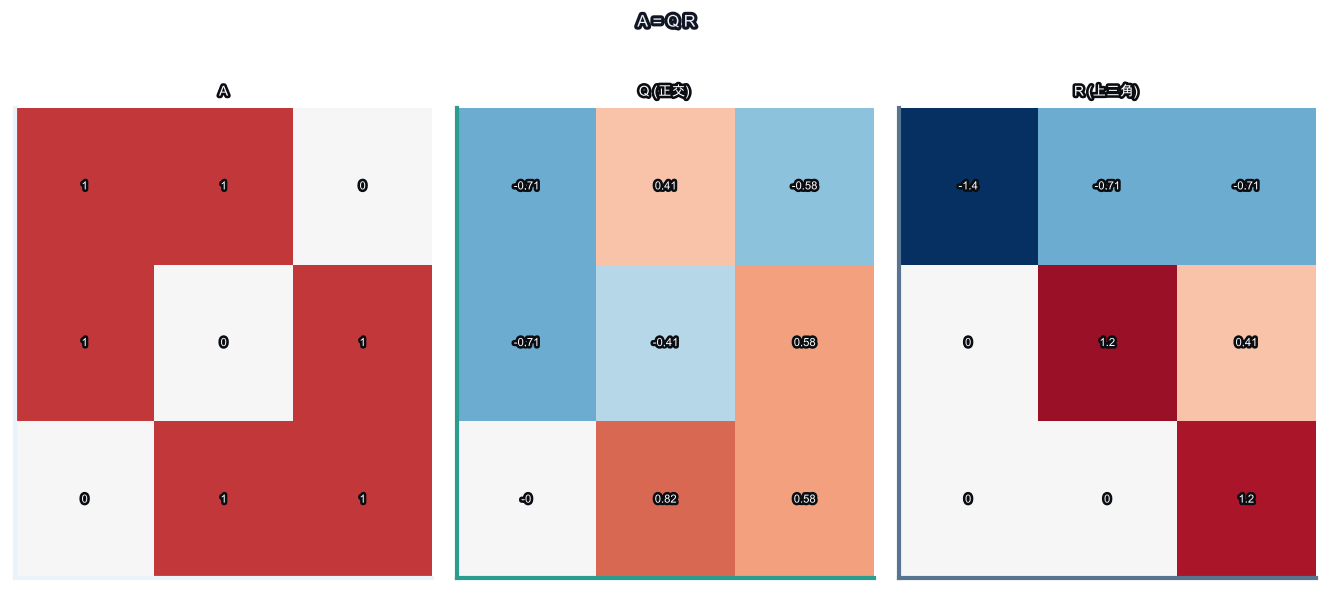

In [8]:
A = np.array([[1.,1,0],[1,0,1],[0,1,1]])
Q, R = np.linalg.qr(A)
assert np.allclose(Q @ R, A) and np.allclose(Q.T @ Q, np.eye(3))
show_factorization(A, [Q, R], ['Q (正交)', 'R (上三角)'],
                   modes=['#2A9D8F', '#577590'], title='A = Q R');

## 3. S = QΛQᵀ（对称矩阵（symmetric matrix）的特征分解（eigendecomposition） / 谱定理（spectral theorem））

对称矩阵 → 正交的特征向量 Q + 对角的特征值 Λ。对应你在 `L17` 学的对角化（diagonalization）。

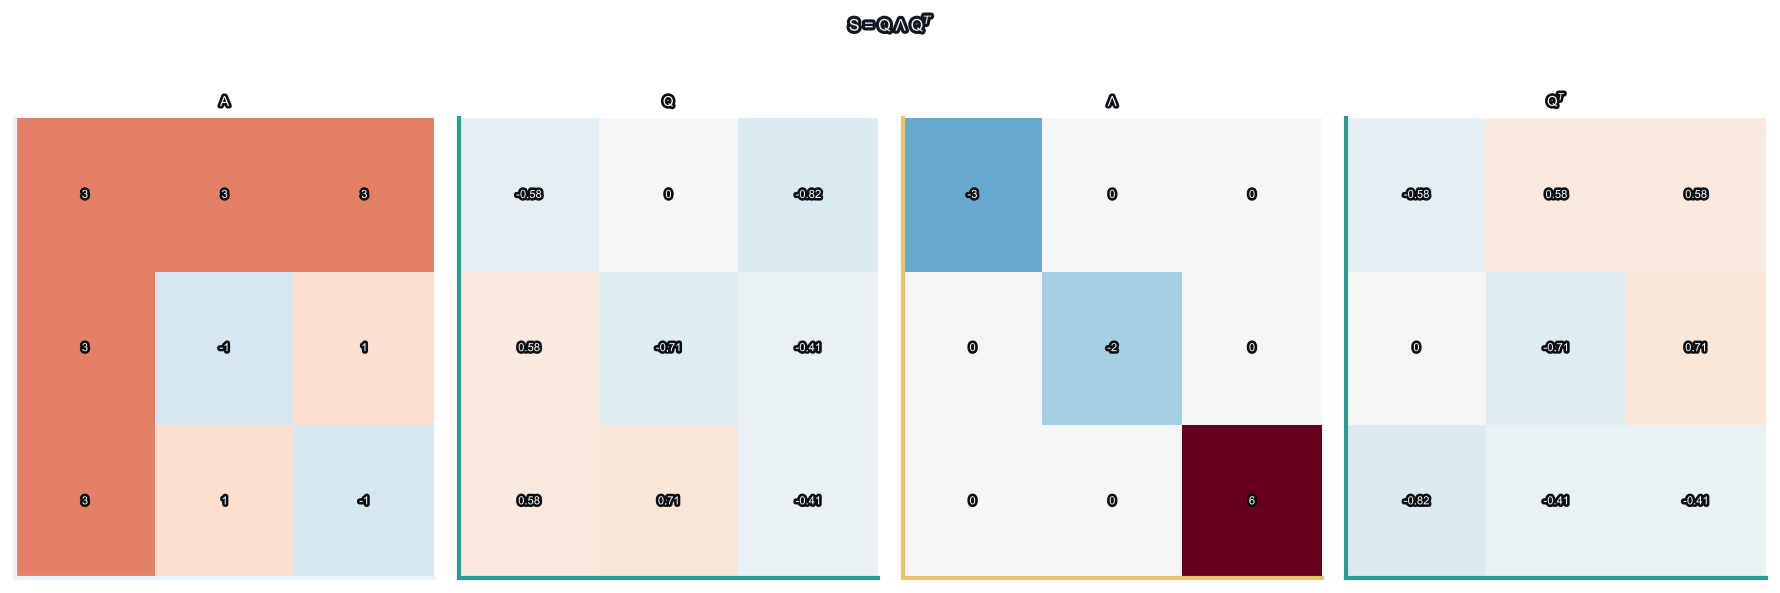

In [9]:
S = np.array([[3.,3,3],[3,-1,1],[3,1,-1]])    # L17 的同一个例子
vals, Q = np.linalg.eigh(S)
Lam = np.diag(vals)
assert np.allclose(Q @ Lam @ Q.T, S)
show_factorization(S, [Q, Lam, Q.T], ['Q', 'Λ', 'Qᵀ'],
                   modes=['#2A9D8F', '#E9C46A', '#2A9D8F'], title='S = Q Λ Qᵀ');

### 停一下：为什么对称矩阵的特征向量会自动两两垂直？

想象对称矩阵像一面"公平的哈哈镜"：不管从哪个方向照过去，它对每个方向的"变形"都遵循同一套相互制衡的规律，不会出现"牺牲方向A的信息去偏袒方向B"这种不对称的扭曲。这种"公平性"（数学上就是 $S=S^\top$）直接导致它的主轴（特征向量）必须互相垂直——这不是巧合，是可以证明的。

**证明思路（只用点乘，高中水平就能跟上）**：

设 $v_1, v_2$ 是对称矩阵 $S$ 的两个特征向量，对应两个**不同**的特征值 $\lambda_1 \neq \lambda_2$，即 $Sv_1 = \lambda_1 v_1$，$Sv_2 = \lambda_2 v_2$。

算一下 $v_1 \cdot (Sv_2)$：把 $Sv_2$ 替换成 $\lambda_2 v_2$，得到 $v_1\cdot(Sv_2) = \lambda_2 (v_1\cdot v_2)$。

再换个算法：因为 $S$ 对称（$S=S^\top$），有一个关键小技巧——把 $S$ 从点乘的左边挪到右边，点乘结果不变（转置对点乘没有影响），所以 $v_1\cdot(Sv_2) = (Sv_1)\cdot v_2$。而 $(Sv_1)\cdot v_2 = (\lambda_1 v_1)\cdot v_2 = \lambda_1(v_1\cdot v_2)$。

两种算法算的是**同一个数**，所以：

$$\lambda_2 (v_1\cdot v_2) = \lambda_1 (v_1\cdot v_2) \quad\Longrightarrow\quad (\lambda_1-\lambda_2)(v_1\cdot v_2) = 0$$

因为 $\lambda_1\neq\lambda_2$，只能是 $v_1\cdot v_2=0$——两个特征向量必须垂直！这正是"对称"这个代数条件 $S=S^\top$ 直接推出的几何结果。一般（非对称）矩阵没有 $S=S^\top$，上面第二步的等式就不成立，特征向量也就没有必须垂直的理由。

**那对称矩阵 $S=Q\Lambda Q^\top$ 和一般矩阵 $A=U\Sigma V^\top$ 是什么关系？**

回到"转-拉伸-转"的比喻：一般情况下，"把输入转向对齐"（$V^\top$ 的工作）和"最后转到摆放位置"（$U$ 的工作）完全可以是两种不同的转法——因为输入空间和输出空间可能维度都不一样。但对称矩阵有个特殊之处：它永远是方阵，输入空间和输出空间是**同一个**空间，而且上面刚证明的"公平性"使得"转向对齐"和"转到最终位置"恰好可以用同一组坐标轴完成，不需要两组不同的基。这就是为什么对称矩阵的公式里只出现一个 Q（同时充当"左边的 U"和"右边的 V"）。

另外，$\Lambda$ 里的特征值可以是负的（表示"沿这个方向反向翻转再拉伸"），而 SVD 里 $\Sigma$ 的奇异值规定必须非负——因为方向的正负已经被拆到 U 和 V 各自的旋转里去了，$\Sigma$ 里只留纯粹的"拉伸倍数"。可以说：**SVD 是给任意矩阵设计的最通用公式；$S=Q\Lambda Q^\top$ 是"对称矩阵"这个特例下的简化版**——对称性帮你省掉了"要不要用两组不同基"的麻烦。

下面用刚才的 S 和 Q 亲手验证一下证明里那个关键等式。

In [10]:
# 补充实验：亲手验证“对称 ⟹ 特征向量正交”背后的等式
v1, v2 = Q[:, 0], Q[:, 1]
lhs = v1 @ (S @ v2)   # v1 · (S v2)
rhs = (S @ v1) @ v2   # (S v1) · v2
print('v1·(Sv2) =', round(lhs, 6), '   (Sv1)·v2 =', round(rhs, 6), ' → 两者相等，这正是 S=Sᵀ 的体现')
print('v1·v2 =', round(v1 @ v2, 10), ' → 因为两个特征值不同，只能靠“垂直”让上面的等式成立')


v1·(Sv2) = -0.0    (Sv1)·v2 = -0.0  → 两者相等，这正是 S=Sᵀ 的体现
v1·v2 = 0.0  → 因为两个特征值不同，只能靠“垂直”让上面的等式成立


## 4. A = UΣVᵀ（奇异值分解（singular value decomposition，SVD） SVD，任意矩阵都有）

左奇异向量 U + 奇异值 Σ + 右奇异向量 Vᵀ。`L14` 的 SVD，这里画出来。

### 停一下：奇异值到底是什么？为什么不直接叫"拉伸倍数"？

想象你在揉一块橡皮泥。揉的过程可以拆成三步：① 先把橡皮泥转个方向，对齐到某几个特定的轴上；② 沿着这几个轴分别把它拉长或压扁一定倍数；③ 最后再转个方向，摆到你想要的最终位置。SVD 说的就是这件事——任何矩阵 $A$（也就是任何线性变换）都可以拆成"转 → 拉伸 → 转"三步：$A = U\Sigma V^\top$。

**奇异值**就是第②步"拉伸了多少倍"这个数字。那为什么不直接叫它"拉伸倍数"，非要取个新名字？因为它和"特征值"是近亲但不完全一样：特征值只对**方阵**定义，而且要求"拉伸前后方向不变"（沿特征向量方向变换后还指向原方向）；奇异值对**任意形状**（甚至行数列数不同）的矩阵都能定义，而且"拉伸前的方向"（输入空间里的方向）和"拉伸后落在的方向"（输出空间里的方向）可以完全不同——毕竟输入和输出可能压根不是同一个空间。为了区分这两种不同性质的"倍数"，才分别取名"特征值"和"奇异值"。两者的关系：对**对称矩阵**，奇异值就是特征值的绝对值；对一般矩阵，奇异值是 $A^\top A$（或 $AA^\top$）特征值的平方根。

在看下面 2×3 的例子之前，先看一个不绕弯子的 2×2 例子——这个矩阵本身就是对角矩阵，除了"拉伸"什么都不做，奇异值和"拉伸倍数"完全重合，一眼就能验证。

In [11]:
import numpy as np

# 补充实验：最简单的 2x2 例子——奇异值就是拉伸倍数，一目了然
A2 = np.array([[3., 0.], [0., 1.]])   # 只做拉伸，不做旋转
U2, s2, Vt2 = np.linalg.svd(A2)
print('奇异值 =', s2)
print('把 e1=(1,0) 喂给 A2:', A2 @ np.array([1., 0.]), ' → 长度变成', s2[0], '(即被拉伸了3倍)')
print('把 e2=(0,1) 喂给 A2:', A2 @ np.array([0., 1.]), ' → 长度变成', s2[1], '(拉伸1倍，即不变)')

print('\n再看形状对应关系：为什么 A 是 2×3 这种非方阵时，U/Σ/Vᵀ 分别是这些形状？')
print('这里有两种"版本"，跟前面 reduced QR / full QR 是同一回事：')
print('  · 完整版（`np.linalg.svd(A)` 默认 full_matrices=True）：')
print('      Vᵀ 是 n×n，完整转动整个 n 维输入空间；Σ 是 m×n，形状和 A 一样（多余部分补0）；U 是 m×m。')
print('  · 经济版（notebook 下面的代码显式传了 full_matrices=False）：')
print('      只保留 r=min(m,n) 个"真正有用"的方向：Vᵀ变成 r×n，Σ变成干净的 r×r 方阵，U变成 m×r。')
print('两种版本算出来的 A 完全一样，经济版只是把"反正拉伸倍数为0、白算"的方向提前丢掉了——')
print('这和本课最后"丢掉小奇异值做低秩近似"是同一个思路的自然结果。')

A23 = np.array([[3., 1., 1.], [1., 3., 1.]])   # 2×3，和下面 af04e8c5 用的是同一个 A
U_full, s_full, Vt_full = np.linalg.svd(A23, full_matrices=True)
U_eco, s_eco, Vt_eco = np.linalg.svd(A23, full_matrices=False)
print('\n完整版 full_matrices=True :  U', U_full.shape, ' Σ对角值', s_full.shape, ' Vᵀ', Vt_full.shape)
print('经济版 full_matrices=False:  U', U_eco.shape, ' Σ对角值', s_eco.shape, ' Vᵀ', Vt_eco.shape)
print('→ 下面 af04e8c5 用的是经济版，所以看到的 Vᵀ 是 2×3，Σ(=diag(s)) 是 2×2，不是 3×3。')


奇异值 = [3. 1.]
把 e1=(1,0) 喂给 A2: [3. 0.]  → 长度变成 3.0 (即被拉伸了3倍)
把 e2=(0,1) 喂给 A2: [0. 1.]  → 长度变成 1.0 (拉伸1倍，即不变)

再看形状对应关系：为什么 A 是 2×3 这种非方阵时，U/Σ/Vᵀ 分别是这些形状？
这里有两种"版本"，跟前面 reduced QR / full QR 是同一回事：
  · 完整版（`np.linalg.svd(A)` 默认 full_matrices=True）：
      Vᵀ 是 n×n，完整转动整个 n 维输入空间；Σ 是 m×n，形状和 A 一样（多余部分补0）；U 是 m×m。
  · 经济版（notebook 下面的代码显式传了 full_matrices=False）：
      只保留 r=min(m,n) 个"真正有用"的方向：Vᵀ变成 r×n，Σ变成干净的 r×r 方阵，U变成 m×r。
两种版本算出来的 A 完全一样，经济版只是把"反正拉伸倍数为0、白算"的方向提前丢掉了——
这和本课最后"丢掉小奇异值做低秩近似"是同一个思路的自然结果。

完整版 full_matrices=True :  U (2, 2)  Σ对角值 (2,)  Vᵀ (3, 3)
经济版 full_matrices=False:  U (2, 2)  Σ对角值 (2,)  Vᵀ (2, 3)
→ 下面 af04e8c5 用的是经济版，所以看到的 Vᵀ 是 2×3，Σ(=diag(s)) 是 2×2，不是 3×3。


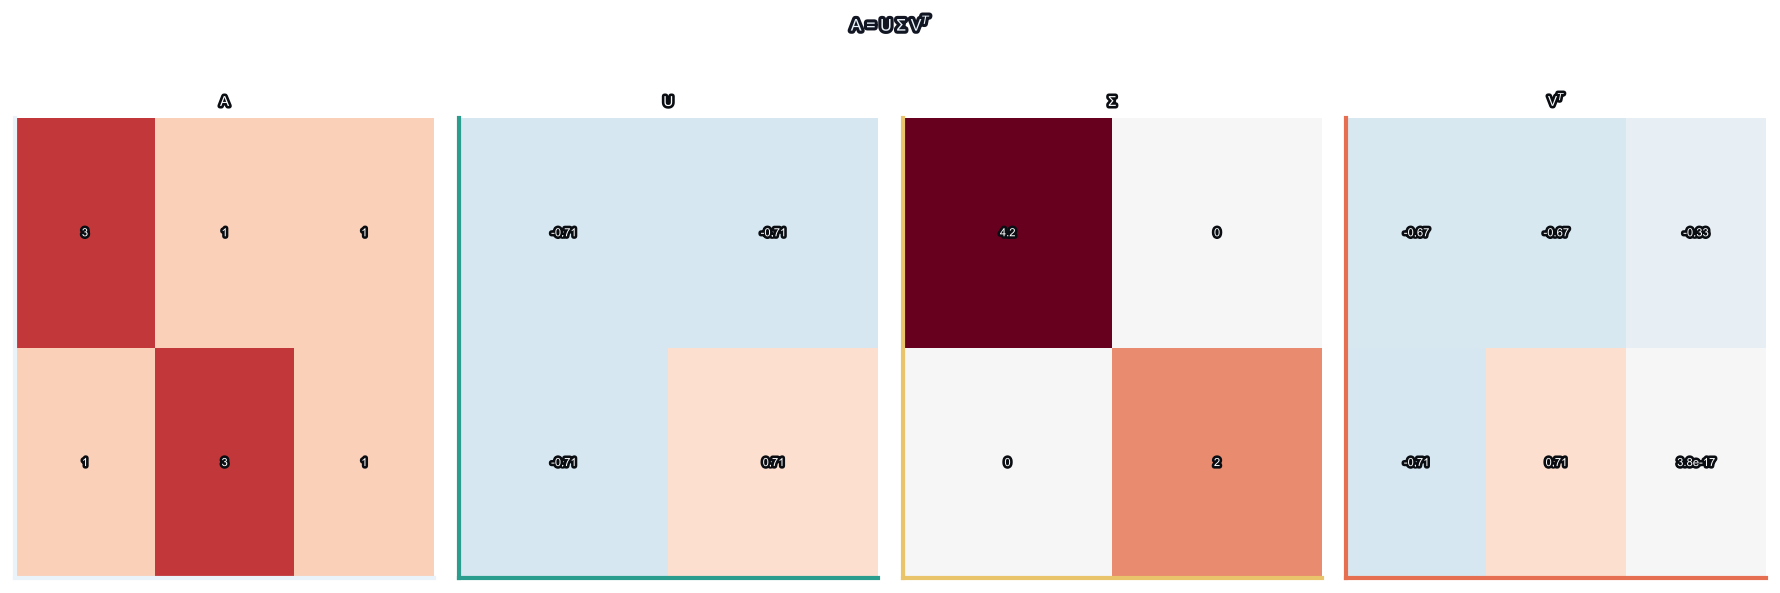

In [12]:
A = np.array([[3.,1,1],[1,3,1]])
U, s, Vt = np.linalg.svd(A, full_matrices=False)
Sig = np.diag(s)
assert np.allclose(U @ Sig @ Vt, A)
show_factorization(A, [U, Sig, Vt], ['U', 'Σ', 'Vᵀ'],
                   modes=['#2A9D8F', '#E9C46A', '#E76F51'], title='A = U Σ Vᵀ');

### 停一下：把上面的 2×3 例子逐步拆开算一遍

上面 `A` 是 2 行 3 列，也就是把一个 3 维输入向量变成一个 2 维输出向量。上面代码用的是"经济版"SVD（`full_matrices=False`），所以这里的 `Vt` 形状是 2×3、`Sig` 是 2×2——`Vᵀ` 这一步已经把"转向"和"只保留有用的2个方向"合并完成了，直接把 3 维输入压缩到 2 维。跟着代码打印每一步的形状变化，看清楚这个"合并"具体发生在哪一步。

In [13]:
# 补充实验：一步步跟踪经济版 A = U Σ Vᵀ 的每一步形状变化
x_test = np.array([1., 0., 0.])   # 3维输入空间里的一个向量

print('Vt shape =', Vt.shape, ' Sig shape =', Sig.shape, ' U shape =', U.shape)

step1 = Vt @ x_test    # 第一步：Vᵀ(2×3) 把 3维输入直接投影到 2维——“转向”与“保留有效方向”一步做完
step2 = Sig @ step1    # 第二步：Σ(2×2) 在这 2维里按奇异值拉伸
step3 = U @ step2      # 第三步：U(2×2) 在 2维输出空间里再转一次

print('\n原始输入 x (3维):                 ', x_test)
print('第1步 Vᵀx (直接变成2维，已经转向+压缩):', np.round(step1, 4))
print('第2步 ΣVᵀx (仍是2维，被拉伸):         ', np.round(step2, 4))
print('第3步 UΣVᵀx (2维，最终输出):          ', np.round(step3, 4))
print('直接算 A@x：                        ', np.round(A @ x_test, 4), ' ← 应与第3步一致')


Vt shape = (2, 3)  Sig shape = (2, 2)  U shape = (2, 2)

原始输入 x (3维):                  [1. 0. 0.]
第1步 Vᵀx (直接变成2维，已经转向+压缩): [-0.6667 -0.7071]
第2步 ΣVᵀx (仍是2维，被拉伸):          [-2.8284 -1.4142]
第3步 UΣVᵀx (2维，最终输出):           [3. 1.]
直接算 A@x：                         [3. 1.]  ← 应与第3步一致


**🔗 Aurora**：SVD 用于推荐(矩阵分解)、embedding 降维、LoRA；对称特征分解 = PCA。下一节 `L21`：把这些"矩阵视角"对准 Aurora 的音频核心。

### 停一下：下面代码里检查 U 用 `U.T@U=I`，检查 Vt 却用 `Vt@Vt.T=I`，这不对称吗？

其实说的是同一件事，只是"谁的行、谁的列"不一样。回忆前面讲过的："某个矩阵的列两两正交" $\iff$ 这个矩阵的转置乘自己 $=I$。也就是说，检查"矩阵 M 的列是否正交"，公式永远是 $M^\top M = I$。

现在 U 本身就是"标准形态"——U 的**列**就是左奇异向量，所以检查写成 $U^\top U = I$，天经地义。

但 `Vt` 这个变量，本身已经是 $V$ 的转置了（`Vt = V.T`）！所以"V 的列"，对应到 `Vt` 这个变量身上，就变成了"`Vt` 的**行**"（转置会把列变成行）。如果我们想检查"V 的列正交"，但手头只有 `Vt`，该怎么写？

- 如果先还原出 `V = Vt.T`，再检查"V 的列正交"，写法应该是 `V.T @ V = I`。
- 但更省事的写法是直接对 `Vt` 操作："检查 Vt 的行正交"，这就是 `Vt @ Vt.T = I`（矩阵乘自己的转置，检查的是**行**与行的点积表，逻辑跟前面 $M^\top M=I$ 检查列与列完全对称，只是把"列"换成了"行"）。

所以 `U.T@U=I` 和 `Vt@Vt.T=I` 看起来形式不同，其实分别是："检查 U 的**列**" 和 "检查 Vt 的**行**"——而 Vt 的行，正好就是 V 的列。两条公式殊途同归，说的都是"这组正交基两两垂直、长度为1"。下面用代码把 `Vt` 的行和 `V` 的列对照打印一遍，眼见为实。

In [14]:
# 补充实验：U 和 Vt 的"正交检查"为什么长得不一样（复用上面 A=UΣVᵀ 的例子）
V_full = Vt.T   # 还原出 V 本身
print('Vt 的第0行 与 V 的第0列 是否相同：', np.allclose(Vt[0], V_full[:, 0]))
print('\nU 检查"列"正交:       U.T @ U =\n', np.round(U.T @ U, 10))
print('\nVt 检查"行"正交:      Vt @ Vt.T =\n', np.round(Vt @ Vt.T, 10))
print('\n等价地，V 检查"列"正交: V.T @ V =\n', np.round(V_full.T @ V_full, 10))
print('\n→ 三种写法说的是同一件事：这组正交基两两垂直、长度为1，只是“主语”从 U/Vt/V 换来换去。')


Vt 的第0行 与 V 的第0列 是否相同： True

U 检查"列"正交:       U.T @ U =
 [[1. 0.]
 [0. 1.]]

Vt 检查"行"正交:      Vt @ Vt.T =
 [[ 1. -0.]
 [-0.  1.]]

等价地，V 检查"列"正交: V.T @ V =
 [[ 1. -0.]
 [-0.  1.]]

→ 三种写法说的是同一件事：这组正交基两两垂直、长度为1，只是“主语”从 U/Vt/V 换来换去。


In [15]:
import numpy as np

# 四大分解数学性质断言（独立运行，无需学生实现）
A = np.array([[3., 1., 1.], [1., 3., 1.]])   # 2×3 矩阵

# SVD：A = U Σ Vᵀ，U 和 V 均正交，奇异值非负且降序
U, s, Vt = np.linalg.svd(A, full_matrices=False)
assert np.allclose(U @ np.diag(s) @ Vt, A, atol=1e-12), "SVD 重建 A=UΣVᵀ 失败"
assert np.allclose(U.T @ U, np.eye(U.shape[1]), atol=1e-12), "U 应满足 UᵀU=I（列正交）"
assert np.allclose(Vt @ Vt.T, np.eye(Vt.shape[0]), atol=1e-12), "V 应满足 VVᵀ=I（行正交）"
assert all(s >= 0), "奇异值应非负"
assert all(s[i] >= s[i+1] for i in range(len(s)-1)), "奇异值应降序排列"
print(f"SVD ✅  奇异值={np.round(s, 4)}，降序排列，U/V 列正交")

# QR：Q 列正交，R 上三角（对角元素符号随实现变化，但 QR=A 成立）
B = np.array([[1.,1.,0.],[1.,0.,1.],[0.,1.,1.]])
Q, R = np.linalg.qr(B)
assert np.allclose(Q @ R, B, atol=1e-12), "QR 重建 A=QR 失败"
assert np.allclose(Q.T @ Q, np.eye(Q.shape[1]), atol=1e-12), "Q 应满足 QᵀQ=I"
assert np.allclose(np.tril(R, -1), 0, atol=1e-12), "R 应为上三角矩阵"
print(f"QR  ✅  R 对角={np.round(np.diag(R), 4)}，QᵀQ=I，R 上三角")

# 秩亏矩阵：SVD 奇异值中接近0的个数 = 零空间维度
A_rank1 = np.outer([1., 2., 3.], [4., 5., 6.])
s_rank1 = np.linalg.svd(A_rank1, compute_uv=False)
zero_singular = np.sum(s_rank1 < 1e-10)
assert zero_singular == 2, f"秩1的3×3矩阵应有2个零奇异值，得到 {zero_singular}"
print(f"秩亏 ✅  外积矩阵奇异值={np.round(s_rank1, 6)}，2个≈0，秩=1")
print("\n所有分解数学性质验证通过 ✅")

SVD ✅  奇异值=[4.2426 2.    ]，降序排列，U/V 列正交
QR  ✅  R 对角=[-1.4142  1.2247  1.1547]，QᵀQ=I，R 上三角
秩亏 ✅  外积矩阵奇异值=[32.83291  0.       0.     ]，2个≈0，秩=1

所有分解数学性质验证通过 ✅


### 停一下：外积（outer product）是什么？为什么秩1矩阵会有2个零奇异值？"秩亏"又是什么意思？

**外积的定义**：给一个列向量 $u$（$m$ 个数）和另一个向量 $v$（$n$ 个数），外积 $u\otimes v$（代码里 `np.outer(u, v)`）定义为一个 $m\times n$ 的矩阵，第 $(i,j)$ 个元素是 $u_i \times v_j$。换句话说，矩阵的第 $i$ 行 $= u_i \times v$（整个 $v$ 向量乘上一个系数）。

**为什么外积一定是秩1？** 因为矩阵的每一行都是同一个向量 $v$ 的某个倍数，所有行彼此之间线性相关——只需要 $v$ 这一个方向，就能把每一行都表示出来。矩阵的"行空间"因此只有1维，这正是"秩为1"的定义：矩阵的行（或列）张成的空间维度是1。

**为什么 SVD 里会出现2个零奇异值？** 回忆 SVD 在做什么："沿着几个互相垂直的方向，各自拉伸一定倍数"。如果一个 $3\times 3$ 矩阵的全部信息都能被"沿着 $v$ 这一个方向"完整表达，那么在跟 $v$ 垂直的另外两个方向上，这个矩阵根本没有拉伸——拉伸倍数是 0。奇异值本来就是在度量"沿每个正交方向到底拉伸了多少"，某方向拉伸倍数为0，就对应一个奇异值为0。所以"矩阵的秩 = 非零奇异值的个数"不是巧合，而是奇异值定义本身决定的。

**"秩亏"（rank deficient）** 只是给"矩阵的秩比它形状允许的最大值小"这件事起的名字：一个 $3\times 3$ 矩阵最多可以秩为3（三个方向都独立、都有拉伸），这里只有秩1，比"满秩"亏了2，所以叫秩亏。

下面复用上一个代码块里已经算好的 `A_rank1` 和 `s_rank1`，拆开看个究竟。

In [16]:
# 补充实验：外积为什么秩1？拆开上面的 A_rank1 看个究竟
print('A_rank1 =\n', A_rank1)
print('第0行 / 第1行 =', np.round(A_rank1[0] / A_rank1[1], 6),
      ' (应该都等于 u[0]/u[1] = 1/2 = 0.5，因为两行都是同一个向量[4,5,6]的倍数)')
print('奇异值 =', np.round(s_rank1, 6), '→ 只有第一个非零，另外两个方向"拉伸倍数"是0')


A_rank1 =
 [[ 4.  5.  6.]
 [ 8. 10. 12.]
 [12. 15. 18.]]
第0行 / 第1行 = [0.5 0.5 0.5]  (应该都等于 u[0]/u[1] = 1/2 = 0.5，因为两行都是同一个向量[4,5,6]的倍数)
奇异值 = [32.83291  0.       0.     ] → 只有第一个非零，另外两个方向"拉伸倍数"是0


### 停一下："条件数"是什么？为什么它一大，求解就不稳定？

想象你在用一把尺子量东西，尺子本身的刻度有一点点误差（比如读数总有 0.1mm 左右的偏差）。如果你量的这个量对误差不敏感，最终结果的误差也很小；但如果这个量对误差有"放大"效应，一点点读数误差会被放大成很大的结果误差。**条件数**（condition number）就是衡量"最坏情况下，输入的误差会被放大多少倍"的一个数字。

**数学定义**：对矩阵 $A$，条件数 $\kappa(A) = \sigma_{\max}/\sigma_{\min}$（最大奇异值除以最小奇异值）。

**为什么下面能通过 QR 的 R 对角线看出条件数？** R 的对角线元素也反映了矩阵在不同方向上的缩放尺度差异（虽然不完全等于奇异值，但同样是"各方向拉伸了多少"的度量）。如果 R 对角线里最大和最小的数字相差悬殊（比如 1000 和 1），说明矩阵把某个方向拉伸了 1000 倍，另一个方向几乎不拉伸（1倍）——这就是"病态"（ill-conditioned）。

**为什么这会导致"求解不稳定"？** 解方程 $Ax=b$ 相当于把 $b$ 沿着每个方向"逆向缩放"回去。如果某个方向被正向拉伸了 1000 倍，求解时就要把这个方向"缩小 1000 倍"变回去。计算机的每一步浮点运算都带着微小的舍入误差（大约 $10^{-16}$ 量级），当这份误差被"缩小"操作反过来放大 1000 倍（或者病态更严重时放大 $10^{10}$ 倍），最终算出的解就可能和真实解相差甚远。这就是数值不稳定的本质：一个原本小到可以忽略的误差，被矩阵自身的结构放大成了不可忽略的误差。

下面直接构造一个条件数为1000的矩阵，往 $b$ 里加一点点扰动，亲眼看看解 $x$ 被放大了多少。

In [17]:
import numpy as np

# 补充实验：条件数大 → 一点点误差被放大很多倍(要挑"最坏方向"的扰动才能看到放大效应)
A_bad = np.array([[1000., 0.], [0., 1.]])   # 条件数 = 1000
b = np.array([1000., 0.])                     # b 主要落在"被强烈拉伸"的方向上
x_exact = np.linalg.solve(A_bad, b)

# 扰动加在"几乎不被拉伸"的方向上（第2个分量），这个方向对误差没有任何"压缩"效果
b_perturbed = b + np.array([0., 1e-3])
x_perturbed = np.linalg.solve(A_bad, b_perturbed)

print('精确解 x =', x_exact)
print('扰动后解 x =', x_perturbed)
rel_b = np.linalg.norm(b_perturbed - b) / np.linalg.norm(b)
rel_x = np.linalg.norm(x_perturbed - x_exact) / np.linalg.norm(x_exact)
print('b 的相对扰动:', rel_b)
print('x 的相对变化:', rel_x)
print('放大倍数 =', rel_x / rel_b, '   κ(A) =', np.linalg.cond(A_bad), ' → 两者量级一致')
print('→ 关键在于：扰动恰好落在"矩阵几乎不拉伸"的方向上，没有被矩阵结构"压小"，')
print('  于是这一点点误差原封不动地传到了解里，相对于本来就很小的 x 分量，显得被"放大"了很多。')


精确解 x = [1. 0.]
扰动后解 x = [1.    0.001]
b 的相对扰动: 1e-06
x 的相对变化: 0.001
放大倍数 = 1000.0000000000001    κ(A) = 1000.0  → 两者量级一致
→ 关键在于：扰动恰好落在"矩阵几乎不拉伸"的方向上，没有被矩阵结构"压小"，
  于是这一点点误差原封不动地传到了解里，相对于本来就很小的 x 分量，显得被"放大"了很多。


In [18]:
import numpy as np

# 参数实验：不同条件数的矩阵，各分解的数值稳定性
for cond_target in [1, 10, 1000]:
    s_vals = np.array([float(cond_target), 1.0])
    A = np.array([[s_vals[0],0.],[0.,s_vals[1]]])
    kappa = np.linalg.cond(A)
    _, r = np.linalg.qr(A)
    print(f'κ={kappa:.0f}  QR R 对角={np.round(np.diag(r),4)}')
print('→ 条件数越大，R 的对角线元素差距越大，方程组求解越不稳定。')


κ=1  QR R 对角=[1. 1.]
κ=10  QR R 对角=[10.  1.]
κ=1000  QR R 对角=[1000.    1.]
→ 条件数越大，R 的对角线元素差距越大，方程组求解越不稳定。


## 参数实验：只改一个旋钮

在 SVD 图里，把矩阵从满秩改成秩1（如 `np.outer([1,2],[3,4])`），观察 Σ 中只有第一个奇异值非零，对应只保留一个方向的信息。

## 5. ✏️ 练习：用 SVD 计算数值秩 `rank_from_svd(A)`

`np.linalg.matrix_rank` 的本质：做 SVD，数有多少个奇异值 > threshold。
自己实现一遍——不准调用 `np.linalg.matrix_rank`。

**推理路线**：
1. `U, S, Vt = np.linalg.svd(A)`
2. 设门限 `t = threshold * S[0]`（相对最大奇异值）
3. 返回 `S > t` 的个数

### 停一下：为什么门限是"相对"的（`threshold * S[0]`），而不是一个固定的小数字？

类比：判断一个人是不是"矮个子"，你不会说"低于1米就算矮"，因为这对婴儿和成年人的标准完全不一样——你会说"比同龄人平均身高矮很多"，这是一个相对标准。

奇异值也是同理：不同矩阵的奇异值大小可能差别悬殊——有的矩阵最大奇异值是 1000，有的矩阵最大奇异值是 0.001。如果统一用一个固定的绝对门限（比如 `1e-10`）：

- 当矩阵本身奇异值普遍很小（比如最大只有 `1e-5`）时，`1e-10` 这个门限相对来说太严格了，几乎不可能有奇异值比它还小，于是本该判定为"接近0、可忽略"的方向也会被当成"有效"方向，秩会被算多。
- 反过来如果矩阵奇异值普遍很大（比如最大是 `10000`），`1e-10` 又显得太宽松，任何一点点数值误差产生的"假奇异值"都可能被误判为有效方向。

用 `threshold * S[0]`（`S[0]` 是最大奇异值）就是把门限"绑定"在这个矩阵自己的尺度上——不管矩阵本身数值是大是小，门限都跟着按比例缩放。这样"多小算是0"的标准，是相对这个矩阵自身而言的，不是一个放诸四海皆准的绝对数字。下面用两个尺度悬殊的矩阵直接对比绝对门限和相对门限的判断结果。

In [19]:
import numpy as np

# 补充实验：绝对门限 vs 相对门限
A_tiny = np.array([[1e-5, 0.], [0., 1e-6]])   # 奇异值都很小，但仍然满秩(2个独立方向)
s_tiny = np.linalg.svd(A_tiny, compute_uv=False)
print('A_tiny 的奇异值:', s_tiny)
print('绝对门限 1e-10 判定的"有效方向"个数:', np.sum(s_tiny > 1e-10), '(碰巧算对，纯属矩阵数值不算太小)')

A_big = np.array([[1e8, 0.], [0., 1e-3]])     # 一个方向拉伸巨大，另一个方向几乎不拉伸
s_big = np.linalg.svd(A_big, compute_uv=False)
print('\nA_big 的奇异值:', s_big)
print('绝对门限 1e-10 判定的"有效方向"个数:', np.sum(s_big > 1e-10),
      '(把几乎无效的方向也算进去了——1e-3 相对 1e8 已经是噪声量级)')
print('相对门限 (1e-10 * S[0]) 判定的"有效方向"个数:', np.sum(s_big > 1e-10 * s_big[0]))


A_tiny 的奇异值: [1.e-05 1.e-06]
绝对门限 1e-10 判定的"有效方向"个数: 2 (碰巧算对，纯属矩阵数值不算太小)

A_big 的奇异值: [1.e+08 1.e-03]
绝对门限 1e-10 判定的"有效方向"个数: 2 (把几乎无效的方向也算进去了——1e-3 相对 1e8 已经是噪声量级)
相对门限 (1e-10 * S[0]) 判定的"有效方向"个数: 1


In [20]:
import numpy as np

def rank_from_svd(A, threshold=1e-10):
    """用 SVD 计算矩阵数值秩（不调用 np.linalg.matrix_rank）"""
    A = np.asarray(A, float)
    # ✏️ TODO: svd → 数奇异值 > threshold * S[0] 的个数
    raise NotImplementedError('请实现 rank_from_svd')

# 验证
try:
    # 满秩矩阵
    A_full = np.array([[1.,2.],[3.,4.]])
    assert rank_from_svd(A_full) == 2, '满秩 2×2 应返回秩 2'

    # 秩亏矩阵（行相关）
    A_rank1 = np.outer([1., 2., 3.], [4., 5., 6.])  # 外积 → 秩 1
    assert rank_from_svd(A_rank1) == 1, f'秩1矩阵应返回 1，得到 {rank_from_svd(A_rank1)}'

    # 矩形矩阵
    A_rect = np.array([[1.,0.,0.],[0.,1.,0.]])       # 2×3，秩 2
    assert rank_from_svd(A_rect) == 2, '矩形满行秩矩阵应返回 2'

    # 与 numpy 对比
    rng = np.random.default_rng(42)
    A_rand = rng.standard_normal((5, 4))
    assert rank_from_svd(A_rand) == np.linalg.matrix_rank(A_rand), '与 numpy 结果不一致'

    print('✅ 通过：rank_from_svd 在满秩、秩亏、矩形四种情形均正确')
except (NotImplementedError, TypeError):
    print('⬆️  先把 rank_from_svd 实现完再运行')


⬆️  先把 rank_from_svd 实现完再运行


### 停一下：算出秩之后能干嘛？亲手做一次"低秩近似 / 去噪"

想象一张老照片，扫描后带了一些随时间产生的细小噪点。如果这张照片本身的主要内容很简单（比如就是几条线组成的图案），那么它的"真正信息"可以用很少几个"模式"完整描述；噪点则近乎均匀地混在所有很小的奇异值里（因为随机噪声不偏向任何一个特定方向）。丢掉那些很小的奇异值，相当于把"次要的、看起来像噪声的细节"滤掉，只保留"占主导地位的几个模式"。

**具体操作步骤**：
1. 做 SVD：`U, S, Vt = np.linalg.svd(A)`
2. 只留前 `k` 个奇异值，把其余的设成 0：`S_truncated = S.copy(); S_truncated[k:] = 0`
3. 重建："压缩版"矩阵 `= U @ np.diag(S_truncated) @ Vt`。因为矩阵乘法里，被设成0的那些奇异值对应的 U、V 的列对结果毫无贡献(0乘上任何数还是0)，所以完全可以只用前 k 列相乘，效果一样，还能省计算量。

下面构造一个"真实信号 + 噪声"的例子，验证截断后是不是真的更接近"真实信号"。

In [21]:
import numpy as np

# 补充实验：截断SVD = 低秩近似 = 去掉"看起来像噪声"的部分
rng = np.random.default_rng(0)
true_signal = np.outer([1., 2., 3., 4.], [1., -1., 1.])   # 真正的信息：秩1
noise = 0.05 * rng.standard_normal(true_signal.shape)       # 一点点随机噪声
A_noisy = true_signal + noise

U_n, s_n, Vt_n = np.linalg.svd(A_noisy, full_matrices=False)
print('奇异值 =', np.round(s_n, 4), ' ← 第1个远大于其余，其余都是噪声量级')

k = 1  # 只留最大的1个奇异值(因为真实信号本来就是秩1)
s_k = s_n.copy()
s_k[k:] = 0
A_denoised = U_n @ np.diag(s_k) @ Vt_n

print('\n去噪前与真实信号的误差:', np.round(np.linalg.norm(A_noisy - true_signal), 4))
print('去噪后与真实信号的误差:', np.round(np.linalg.norm(A_denoised - true_signal), 4))
print('→ 丢掉小奇异值之后，反而更接近"真实信号"，因为噪声主要藏在那些小奇异值里')


奇异值 = [9.4841 0.1113 0.0214]  ← 第1个远大于其余，其余都是噪声量级

去噪前与真实信号的误差: 0.122
去噪后与真实信号的误差: 0.0452
→ 丢掉小奇异值之后，反而更接近"真实信号"，因为噪声主要藏在那些小奇异值里


## 本课收束

现在可以用 `np.linalg.svd(A)` 拿到 U、Σ、Vᵀ，用奇异值序列判断矩阵的有效秩和各方向的信息量。本课 `rank_from_svd` 把「数大于门限的奇异值个数」这条判据手写了一遍——与 L18 的秩判据、L15 的 `classify_system` 同属「矩阵能表达多少独立信息」。

这套分解直接对应 Aurora mel 频谱矩阵的低秩近似：保留前 k 个奇异值即可重建主要频谱结构。下一节 **L21** 把矩阵视角对准音频核心：DFT 矩阵 / Mel 矩阵 = 滤波器组乘法。


### 停一下：Mel 频谱矩阵的"低秩"到底是什么意思？先看一个玩具版

Mel 滤波器组是一排"三角形"形状的加权模板，每个模板负责把频谱在某个频率范围内的能量"收拢"成一个数。相邻的三角形之间通常会有重叠（为了让频率过渡平滑，不产生突变的边界效应）。

这种"大量重叠、彼此相似"的结构，意味着这些模板之间并不是完全独立的——后一个模板某种程度上可以从相邻模板"插值"得到。所以整套模板矩阵的"真正自由度"远小于它的行数（模板个数）。这就是"低秩"在直觉上的含义：矩阵的行（或列）虽然很多，但它们互相高度相关，可以用远少于行数的几个"基本模式"重建出来——和前面"截断SVD做低秩近似"是同一件事。

下面搭一个简化玩具版（真正的 Mel 滤波器组会在 `L21` 详细展开），亲眼看看"一堆重叠的三角形"做 SVD 之后，奇异值是不是真的很快衰减到接近0。

In [22]:
import numpy as np

# 补充实验（预告 L21）：模拟"重叠三角滤波器组"为什么天生低秩
def triangular_filter(center, width, n_points):
    x = np.arange(n_points)
    return np.maximum(0, 1 - np.abs(x - center) / width)

n_freq, n_filters = 40, 6
filterbank = np.array([
    triangular_filter(center=6 + i * 5, width=6, n_points=n_freq)
    for i in range(n_filters)
])
s_fb = np.linalg.svd(filterbank, compute_uv=False)
print('滤波器组形状:', filterbank.shape)
print('奇异值:', np.round(s_fb, 3))
print(f'→ 前几个奇异值远大于后面的，说明这 {n_filters} 个"重叠三角形"模板并不是互相独立的，')
print('  只需要少数几个"方向"就能大致重建整套滤波器组——这就是 L21 要用到的"低秩"性质。')


滤波器组形状: (6, 40)
奇异值: [2.626 2.448 2.171 1.824 1.454 1.136]
→ 前几个奇异值远大于后面的，说明这 6 个"重叠三角形"模板并不是互相独立的，
  只需要少数几个"方向"就能大致重建整套滤波器组——这就是 L21 要用到的"低秩"性质。


### 停一下：自评前，先看这份"及格线"参考

下面的自评表格只有 True/False，容易让人不知道"到什么程度才算通过"。这里给出每一项的具体检验方法：

- **能说出 U、Σ、Vᵀ 各自含义？** 及格线：给你任意一个矩阵 A，你能不看 notebook，讲出"Vᵀ 负责把输入向量转到几个特定方向上（如果是经济版 SVD，还顺带只保留有用的方向）；Σ 告诉我每个方向被拉伸了多少倍；U 负责把结果转到最终输出的方向"。如果某个奇异值是 0，你能说出这意味着那个方向上 A 完全没有拉伸（信息丢失/秩不够）。
- **rank_from_svd 实现并通过断言？** 及格线：跑上面的练习 cell，全部 `assert` 通过；并且你能解释"为什么门限要乘以 S[0]"（提示：前面"绝对门限 vs 相对门限"的补充实验）。
- **理解截断奇异值 = 低秩近似？** 及格线：你能解释"丢掉小奇异值"为什么约等于"去噪"（提示：噪声通常均匀分布在所有方向，包括那些真实信号很弱的方向；真实信号往往只集中在少数几个大奇异值对应的方向上）。
- **读过收束中 L21 矩阵滤波预告？** 及格线：你能说出"Mel 滤波器组为什么天生低秩"这句话背后的直觉（提示：看上面"重叠三角形"的补充实验——模板之间彼此重叠、互相能插值，所以自由度远小于模板个数）。

如果四项里有哪一项你说不出上面这种程度的解释，回去对应的"停一下"小节再看一遍，比直接勾 True 更有用。

In [ ]:
# ✏️ 本课自评
l20_review = {
    "svd_parts_understood":   None,  # 能说出 U、Σ、Vᵀ 各自含义？True/False
    "rank_from_svd_done":     None,  # rank_from_svd 实现并通过断言？True/False
    "low_rank_intuition":     None,  # 理解截断奇异值 = 低秩近似？True/False
    "l21_bridge_read":        None,  # 读过收束中 L21 矩阵滤波预告？True/False
}

unfilled = [k for k, v in l20_review.items() if v is None]
assert not unfilled, f'还未填写：{unfilled}'
weak = [k for k, v in l20_review.items() if v is False]
if weak:
    print(f'⚠️  需要加强：{weak}')
else:
    print('✅ L20 全部通关！进入 L21：矩阵即滤波')


---

→ **下一课**　[L21 · 音频即线代](L21_aurora_matrices.ipynb)

> 下节课将学习 **音频即线代**：DFT 矩阵 / Mel 矩阵：音频处理 = 矩阵乘法。